In [1]:
# # Handwritten Digit Recognition using ANN

# ## What are we going to do?

# - Load the MNIST dataset
# - Explore the dataset
# - Preprocess the images
# - Build an Artificial Neural Network (ANN)
# - Train the model
# - Evaluate the model
# - Predict handwritten digits
# - Save the trained model

# ## Real World Applications

# - Bank Cheque Digit Recognition
# - Postal ZIP Code Recognition
# - Form Digit Recognition
# - ATM Cheque Processing

**Import Required Libraries**

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Why?
# TensorFlow -> Build Deep Learning Model
# Matplotlib ->Display Images
# NumPy -> Work with Arrays

**Load MNIST Dataset**

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# MNIST is a built-in dataset provided by TensorFlow.
# It contains handwritten digits from 0 to 9.
# When we load the dataset, TensorFlow automatically downloads it (only the first time).
# The dataset is already divided into:
# Training Data -> Used to teach the model.
# Testing Data -> Used to check how well the model has learned.


**Explore the Dataset**

In [ ]:
print("Training Images :", X_train.shape)

print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)

print("Testing Labels :", y_test.shape)

# Training Images -> 60,000 images
# Each image size -> 28 × 28 pixels
# Testing Images -> 10,000 images

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


**Display Sample Images**

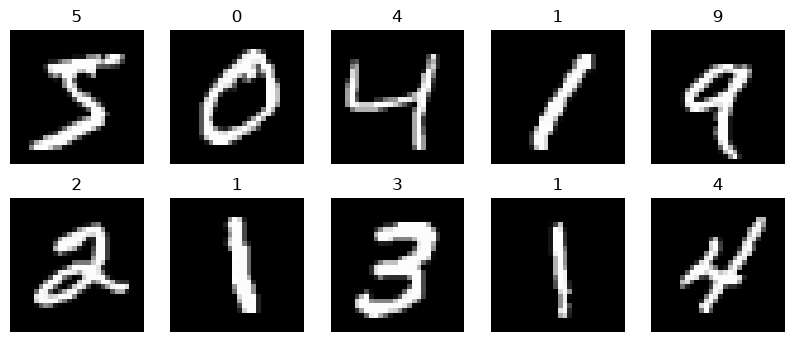

In [ ]:
plt.figure(figsize=(10,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(y_train[i])

    plt.axis("off")

plt.show()

# Explanation
# Before training any AI model,we should always look at the data.
# This helps us understand:
#    Image quality
#    Image size
#    Labels
#    Dataset correctness

**Preprocess the Dataset**

In [7]:
X_train = X_train / 255.0

X_test = X_test / 255.0

**Check Pixel Values**

In [ ]:
print("Minimum Pixel Value :", X_train.min())

print("Maximum Pixel Value :", X_train.max())

# Matlab Normalization Successfully Ho gaya.

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


**Flatten the Images**

In [9]:
X_train = X_train.reshape( 60000, 784 )
X_test = X_test.reshape( 10000, 784 )


**Verify New Shape**

In [10]:
print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (60000, 784)
Testing Shape : (10000, 784)


In [ ]:
# Explanation

# Earlier
# (60000,28,28)

# After Flatten
# (60000,784)

# Ab Har Image Ek Row Ban chuki hai.
# ANN Ab Training Shuru kar sakta hai.

**Build the ANN Model**

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(784,)
    ),
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

View Model Summary

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [17]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics= ["accuracy"]
)

In [ ]:
# Why Compile?

# Socho Ek student exam dene ja raha hai. 
# Usse pehle teacher batata hai Kis method se padhna hai.
# Galti kaise check hogi. Result kaise niklega.
# Model ko bhi training se pehle ye rules batane padte hain.
# Compile wahi karta hai.

Train the Model

In [18]:
history = model.fit(
    X_train, 
    y_train,
    epochs=10, # means  Model pure dataset ko 10 baar dekhenge
    batch_size =32,  
    validation_split = 0.2 # Training Data ka 20% validation ke liye rakh deta hai
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9193 - loss: 0.2831 - val_accuracy: 0.9560 - val_loss: 0.1551
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9624 - loss: 0.1276 - val_accuracy: 0.9641 - val_loss: 0.1209
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0878 - val_accuracy: 0.9685 - val_loss: 0.1063
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9804 - loss: 0.0662 - val_accuracy: 0.9724 - val_loss: 0.0957
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9852 - loss: 0.0503 - val_accuracy: 0.9718 - val_loss: 0.0913
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9885 - loss: 0.0401 - val_accuracy: 0.9722 - val_loss: 0.0958
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9905 - loss: 0.0315 - val_accuracy: 0.9757 - val_loss: 0.0872
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9922 - loss: 0.0255 - 

Display Training History

In [19]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


Evaluate the Model

In [20]:
test_loss,test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9763 - loss: 0.0854
Test Loss:  0.08544295281171799
Test Accuracy:  0.9763000011444092


Predict Handwritten Digits

In [21]:
predictions = model.predict( X_test )

predicted_labels = np.argmax(
    predictions,
    axis=1 # work on column based
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step


**Compare Actual vs Predicted**

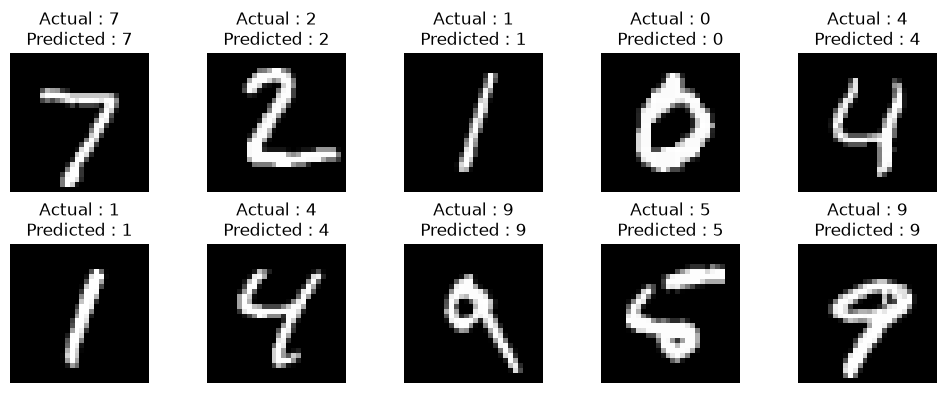

In [26]:
plt.figure(figsize=(10,4))  # figsize=(width,height)

for i in range(10):  # Each iteration displays one image.
    #subplot() divides the figure into smaller sections.
    plt.subplot(2,5,i+1)  # plt.subplot(rows, columns, position)  , Total = 10 boxes

    plt.imshow( # It displays an image stored as a NumPy array.

        X_test[i].reshape(28,28),

        cmap="gray"

    )

    plt.title(

        f"Actual : {y_test[i]}\nPredicted : {predicted_labels[i]}"

    )

    plt.axis("off")

plt.tight_layout()  # This automatically adjusts spacing.

plt.show()

**Summary Table**

| Code                           | Purpose                                                                |
| ------------------------------ | ---------------------------------------------------------------------- |
| `plt.figure(figsize=(10,4))`   | Creates a figure of size 10 × 4 inches.                                |
| `for i in range(10)`           | Loops through the first 10 test images.                                |
| `plt.subplot(2,5,i+1)`         | Divides the figure into a 2 × 5 grid and selects the current position. |
| `X_test[i]`                    | Selects the *i-th* test image.                                         |
| `.reshape(28,28)`              | Ensures the image is in a 28 × 28 format for display.                  |
| `plt.imshow(..., cmap="gray")` | Displays the image in grayscale.                                       |
| `plt.title(...)`               | Shows the actual and predicted labels above the image.                 |
| `\n`                           | Moves the predicted label to the next line.                            |
| `plt.axis("off")`              | Hides the x-axis and y-axis.                                           |
| `plt.tight_layout()`           | Prevents titles and images from overlapping.                           |
| `plt.show()`                   | Displays the complete figure.                                          |


**Save the Model**

In [27]:
model.save("mnist_ann_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


**Project Status**

In [ ]:
# Project 01
# Handwritten Digit Recognition

# ✔ Dataset Loaded
# ✔ Data Preprocessing
# ✔ ANN Model Built
# ✔ Model Training
# ✔ Model Evaluation
# ✔ Prediction
# ✔ Model Saved
# ✔ README
# ✔ Requirements
# Status
# ✅ Completed

Review of This Project

In [ ]:
# Is project me humne practically revise kiya:

# ✅ ANN
# ✅ Dense Layer
# ✅ ReLU
# ✅ Softmax
# ✅ Adam Optimizer
# ✅ Loss Function
# ✅ Epochs
# ✅ Batch Size
# ✅ Model Evaluation
# ✅ Prediction
# ✅ Model Saving